In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

plt.style.use('ggplot')

print("Dashboard KPI Notebook Ready")

Dashboard KPI Notebook Ready


In [4]:
# Load datasets

loads = pd.read_csv("../data/loads.csv")

trips = pd.read_csv("../data/trips.csv")

delivery_events = pd.read_csv("../data/delivery_events.csv")

fuel_purchases = pd.read_csv("../data/fuel_purchases.csv")

maintenance = pd.read_csv("../data/maintenance_records.csv")

print("Core datasets loaded successfully")

Core datasets loaded successfully


In [5]:
# Convert date columns

loads['load_date'] = pd.to_datetime(loads['load_date'])

trips['dispatch_date'] = pd.to_datetime(trips['dispatch_date'])

delivery_events['scheduled_datetime'] = pd.to_datetime(delivery_events['scheduled_datetime'])

fuel_purchases['purchase_date'] = pd.to_datetime(fuel_purchases['purchase_date'])

maintenance['maintenance_date'] = pd.to_datetime(maintenance['maintenance_date'])

print("Date conversion completed")

Date conversion completed


In [6]:
# Executive KPIs

total_revenue = loads['revenue'].sum()

total_loads = loads['load_id'].nunique()

total_trips = trips['trip_id'].nunique()

total_distance = trips['actual_distance_miles'].sum()

avg_mpg = trips['average_mpg'].mean()

on_time_rate = delivery_events['on_time_flag'].mean() * 100

total_fuel_cost = fuel_purchases['total_cost'].sum()

total_maintenance_cost = maintenance['total_cost'].sum()

# Print KPIs

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Loads: {total_loads:,}")
print(f"Total Trips: {total_trips:,}")
print(f"Total Distance: {total_distance:,} miles")
print(f"Average MPG: {avg_mpg:.2f}")
print(f"On-Time Delivery Rate: {on_time_rate:.2f}%")
print(f"Total Fuel Cost: ${total_fuel_cost:,.2f}")
print(f"Total Maintenance Cost: ${total_maintenance_cost:,.2f}")

Total Revenue: $262,525,800.29
Total Loads: 85,410
Total Trips: 85,410
Total Distance: 122,159,201 miles
Average MPG: 6.50
On-Time Delivery Rate: 55.67%
Total Fuel Cost: $95,592,992.04
Total Maintenance Cost: $5,730,573.28


CHART

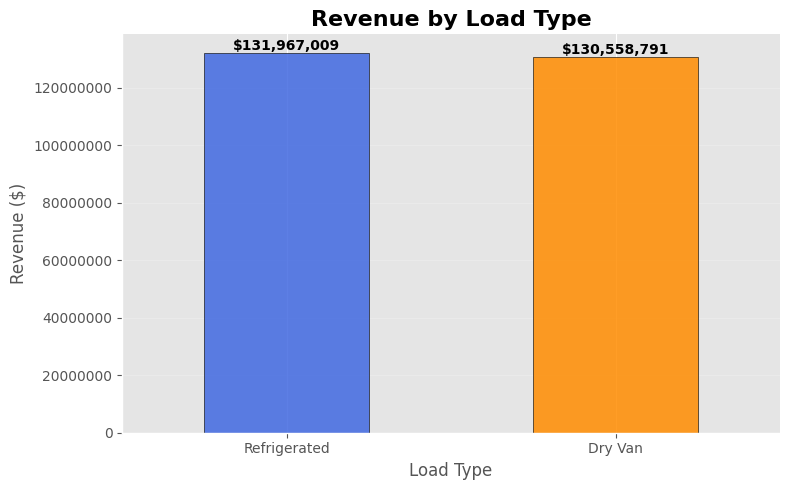

In [7]:
revenue_by_load = loads.groupby('load_type')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

ax = revenue_by_load.plot(
    kind='bar',
    color=['royalblue', 'darkorange'],
    edgecolor='black',
    alpha=0.85
)

# Add labels
for i, value in enumerate(revenue_by_load):
    ax.text(
        i,
        value + 1000000,
        f'${value:,.0f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Revenue by Load Type', fontsize=16, fontweight='bold')
plt.xlabel('Load Type', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)

plt.ticklabel_format(style='plain', axis='y')

plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.2)

sns.despine()

plt.tight_layout()

plt.show()

MONTHLY REVENUE TREND

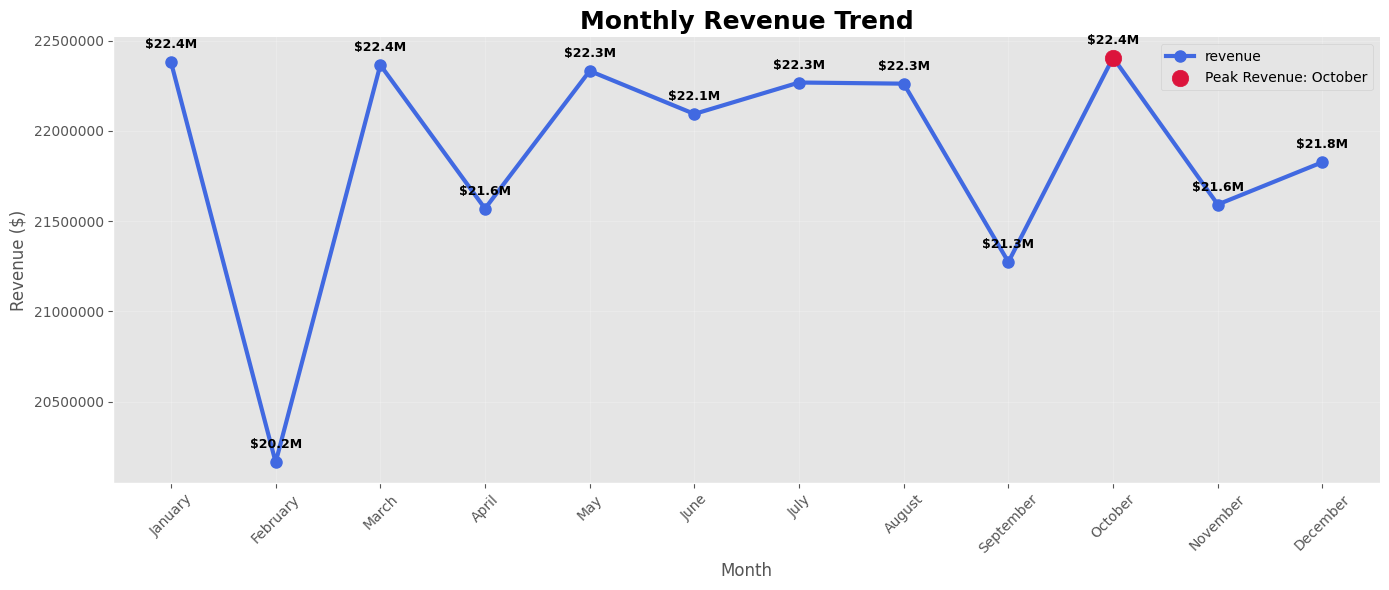

In [8]:

loads['month_name'] = loads['load_date'].dt.month_name()


month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]


monthly_revenue = loads.groupby('month_name')['revenue'].sum()


monthly_revenue = monthly_revenue.reindex(month_order)


plt.figure(figsize=(14,6))


ax = monthly_revenue.plot(
    marker='o',
    linewidth=3,
    color='royalblue',
    markersize=8
)


for i, value in enumerate(monthly_revenue):

    ax.annotate(
        f'${value/1e6:.1f}M',
        (i, value),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )


max_month = monthly_revenue.idxmax()
max_value = monthly_revenue.max()

ax.scatter(
    monthly_revenue.index.get_loc(max_month),
    max_value,
    color='crimson',
    s=140,
    zorder=5,
    label=f'Peak Revenue: {max_month}'
)


ax.set_xticks(range(len(monthly_revenue.index)))
ax.set_xticklabels(monthly_revenue.index, rotation=45)


plt.title(
    'Monthly Revenue Trend',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)

plt.ticklabel_format(style='plain', axis='y')

plt.grid(alpha=0.2)

sns.despine()

plt.legend()


plt.tight_layout()

plt.show()

ON TIME VS LATE

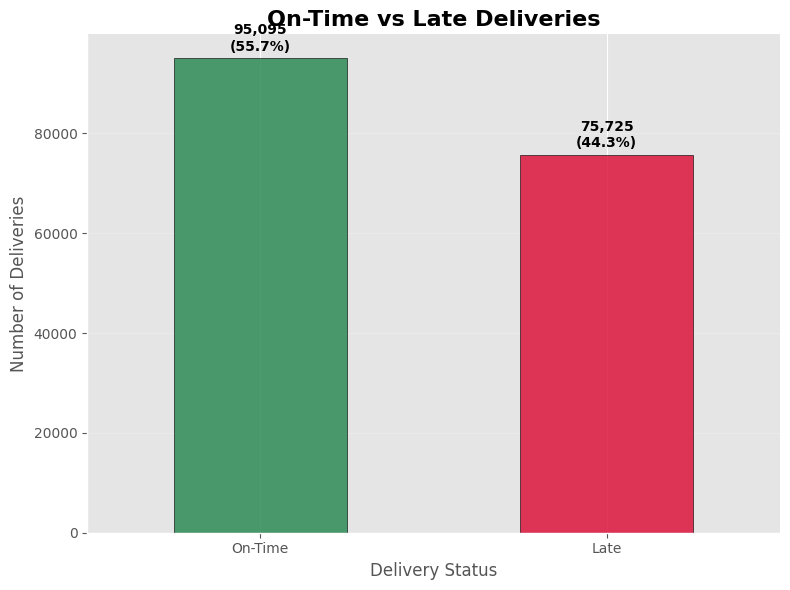

In [9]:
delivery_status = delivery_events['on_time_flag'].value_counts()

delivery_status.index = ['On-Time', 'Late']

percentages = (delivery_status / delivery_status.sum()) * 100

plt.figure(figsize=(8,6))

colors = ['seagreen', 'crimson']

ax = delivery_status.plot(
    kind='bar',
    color=colors,
    edgecolor='black',
    alpha=0.85
)

# Add labels
for i, value in enumerate(delivery_status):
    ax.text(
        i,
        value + 1500,
        f'{value:,}\n({percentages.iloc[i]:.1f}%)',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title('On-Time vs Late Deliveries', fontsize=16, fontweight='bold')
plt.xlabel('Delivery Status', fontsize=12)
plt.ylabel('Number of Deliveries', fontsize=12)

plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.2)

sns.despine()

plt.tight_layout()

plt.show()

Revenue by Booking Type

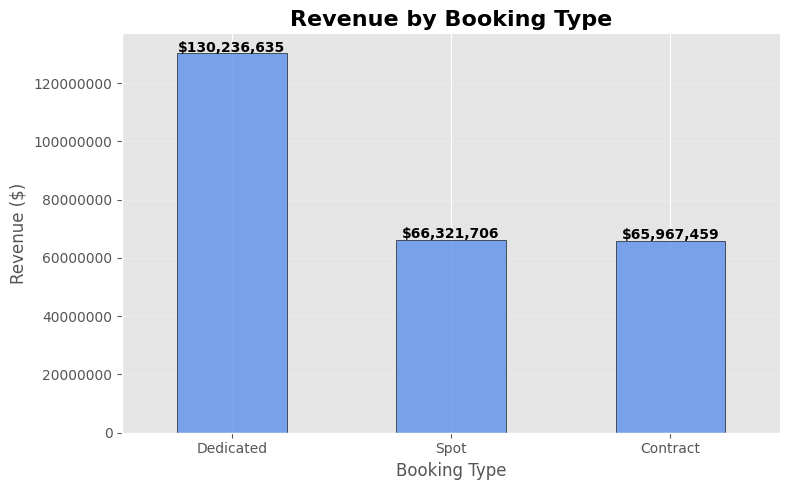

In [10]:
booking_revenue = loads.groupby('booking_type')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

ax = booking_revenue.plot(
    kind='bar',
    color='cornflowerblue',
    edgecolor='black',
    alpha=0.85
)

# Add labels
for i, value in enumerate(booking_revenue):
    ax.text(
        i,
        value + 500000,
        f'${value:,.0f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Revenue by Booking Type', fontsize=16, fontweight='bold')
plt.xlabel('Booking Type', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)

plt.ticklabel_format(style='plain', axis='y')

plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.2)

sns.despine()

plt.tight_layout()

plt.show()

Delay Hotspots by State

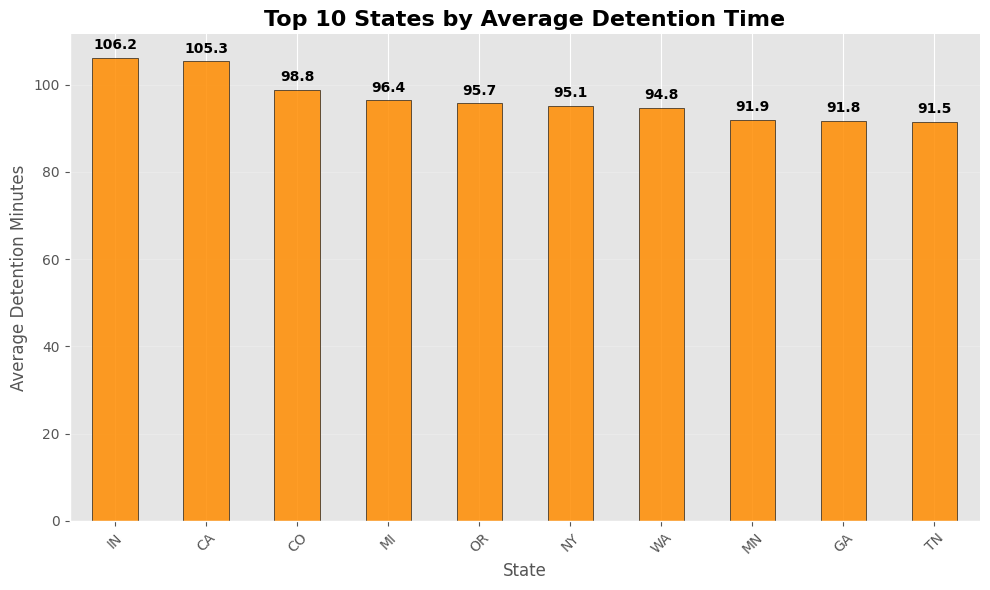

In [11]:
state_detention = delivery_events.groupby('location_state')['detention_minutes'].mean().sort_values(ascending=False)

top_states = state_detention.head(10)

plt.figure(figsize=(10,6))

ax = top_states.plot(
    kind='bar',
    color='darkorange',
    edgecolor='black',
    alpha=0.85
)

# Add labels
for i, value in enumerate(top_states):
    ax.text(
        i,
        value + 2,
        f'{value:.1f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Top 10 States by Average Detention Time', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Average Detention Minutes', fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.2)

sns.despine()

plt.tight_layout()

plt.show()

Maintenance Cost by Type

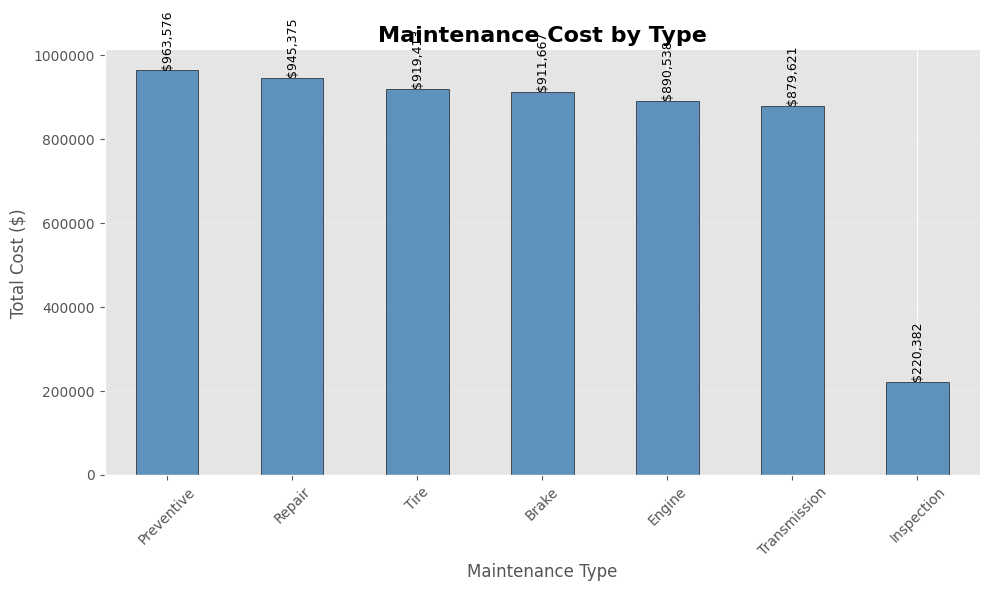

In [12]:
maintenance_by_type = maintenance.groupby('maintenance_type')['total_cost'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

ax = maintenance_by_type.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)

# Add labels
for i, value in enumerate(maintenance_by_type):
    ax.text(
        i,
        value + 10000,
        f'${value:,.0f}',
        ha='center',
        fontsize=9,
        rotation=90
    )

plt.title('Maintenance Cost by Type', fontsize=16, fontweight='bold')
plt.xlabel('Maintenance Type', fontsize=12)
plt.ylabel('Total Cost ($)', fontsize=12)

plt.ticklabel_format(style='plain', axis='y')

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.2)

sns.despine()

plt.tight_layout()

plt.show()

FUEL COST BY STATE

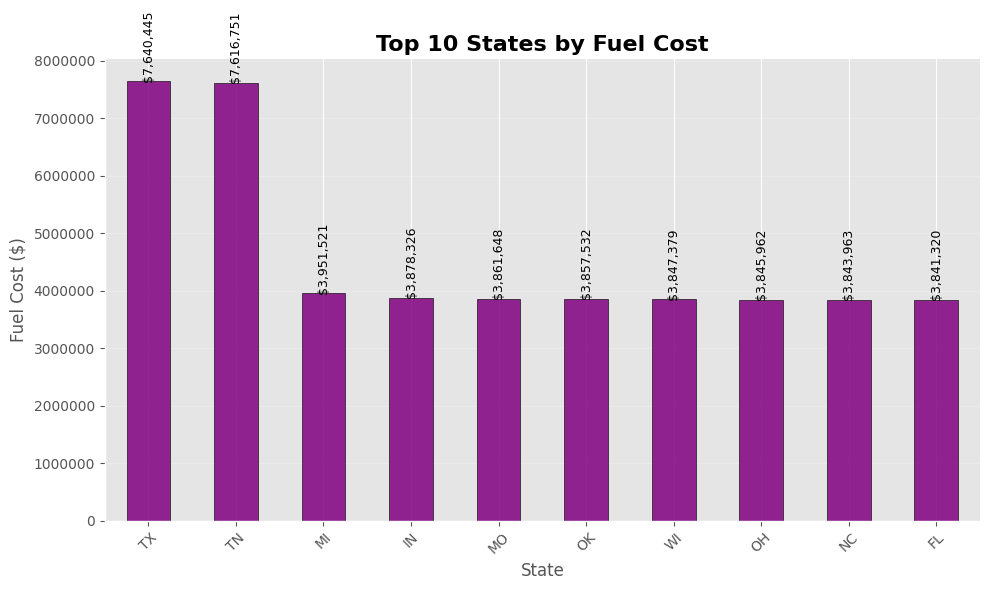

In [13]:
fuel_by_state = fuel_purchases.groupby('location_state')['total_cost'].sum().sort_values(ascending=False)

top_fuel_states = fuel_by_state.head(10)

plt.figure(figsize=(10,6))

ax = top_fuel_states.plot(
    kind='bar',
    color='purple',
    edgecolor='black',
    alpha=0.85
)

# Add labels
for i, value in enumerate(top_fuel_states):
    ax.text(
        i,
        value + 50000,
        f'${value:,.0f}',
        ha='center',
        fontsize=9,
        rotation=90
    )

plt.title('Top 10 States by Fuel Cost', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Fuel Cost ($)', fontsize=12)

plt.ticklabel_format(style='plain', axis='y')

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.2)

sns.despine()

plt.tight_layout()

plt.show()

TOP CUSTOMER BY REVENUE

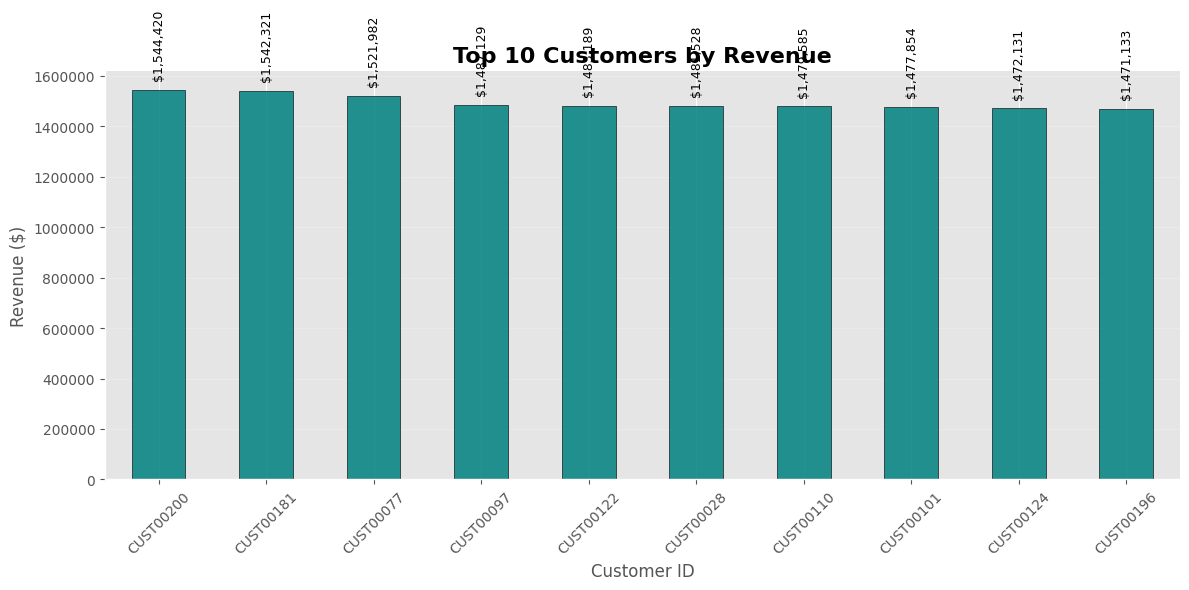

In [14]:
customer_revenue = loads.groupby('customer_id')['revenue'].sum().sort_values(ascending=False)

top_customers = customer_revenue.head(10)

plt.figure(figsize=(12,6))

ax = top_customers.plot(
    kind='bar',
    color='teal',
    edgecolor='black',
    alpha=0.85
)

# Add labels
for i, value in enumerate(top_customers):
    ax.text(
        i,
        value + 50000,
        f'${value:,.0f}',
        ha='center',
        fontsize=9,
        rotation=90
    )

plt.title('Top 10 Customers by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Customer ID', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)

plt.ticklabel_format(style='plain', axis='y')

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.2)

sns.despine()

plt.tight_layout()

plt.show()